# Market Basket Analysis: Frequent Itemsets and Sequential Patterns

**CSCE 676 — Data Mining and Analysis**
**Texas A&M University — Spring 2026**
**Author:** Ahad Hussain (UIN 535007416)


## 1. Introduction & Motivation

Every day, millions of grocery baskets move through online platforms like Instacart. Each
basket is a small window into how people plan meals, manage households, and substitute
products. Across millions of baskets, stable patterns emerge: items that co-occur far more
often than chance would predict, purchase sequences that unfold across visits, and shopper
archetypes that look quite different from one another.

This project mines those patterns from the **Instacart Online Grocery Shopping Dataset 2017**
(~3.4M orders, ~32M order-product lines, ~49K products, ~206K users) and asks four layered
questions:

1. **RQ1 — Support sensitivity.** What association rules exist in the data, and how does
   the choice of minimum support threshold change what we see?
2. **RQ2 — Temporal context.** Do weekend and weekday shoppers — or morning and evening
   shoppers — produce different rules?
3. **RQ3 — Temporal order.** When we treat users' orders as *sequences* rather than bags,
   do we uncover progressions that unordered mining cannot see?
4. **RQ4 — Shopper type.** If we cluster users by what they buy, do different shopper
   archetypes produce different rules?

Each question is a different lens on the same underlying baskets. Together they build an
argument that **one-size-fits-all rule mining leaves a lot of structure on the table** —
and that segmenting by time, order, and user type all surface patterns that global mining
misses.


### 1.1 RQ-to-Method Mapping

| RQ  | Technique                                     | Algorithm            | Course / Beyond       | Key Metrics                                          |
|-----|-----------------------------------------------|----------------------|-----------------------|------------------------------------------------------|
| RQ1 | Frequent itemsets + association rules         | FP-Growth            | Course                | Support, confidence, lift, item diversity, runtime   |
| RQ2 | Segmented frequent itemsets                   | FP-Growth / segment  | Course                | Jaccard of rule sets, segment-exclusive rules, lift  |
| RQ3 | Sequential pattern mining                     | PrefixSpan           | **Beyond course**     | Sequential support, sequential-only patterns         |
| RQ4 | User clustering + cluster-specific rules      | K-Means + FP-Growth  | Course (clustering)   | Silhouette, cluster profiles, cluster-exclusive rules|


### 1.2 Collaboration Declaration

- **Human collaborators:** None. This is an individual project.
- **External resources:** Instacart 2017 public dataset (Kaggle); `mlxtend`, `prefixspan`,
  and `scikit-learn` library documentation; standard references (see end of notebook).
- **AI tools:** Anthropic Claude and OpenAI ChatGPT were used to sanity-check plan
  structure and scaffold boilerplate text. All analytical decisions, parameter choices,
  result interpretation, and code verification are my own.


## 2. Setup & Data Loading

We load the full `order_products__prior` file (~32M rows) and merge it with product, aisle,
and department metadata. Two basket representations are then built:

1. **Department-level baskets** (21 categories) — small enough to run on the **full**
   ~3.2M-order dataset as a dense boolean matrix.
2. **Product-level baskets** (~49K products) — far too large for a dense matrix
   (500K × 49K ≈ 24 GB), so we use `mlxtend`'s **sparse** `TransactionEncoder` on a
   500K-order random sample.

We also build two derived artifacts used in later sections:

- **User × department frequency matrix** (for RQ4 clustering)
- **Per-user dominant-department sequences** (for RQ3 PrefixSpan)


In [1]:
# Core imports
import os
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

def md(text): display(Markdown(text))
def md_table(df, title=None, n=None):
    if title: display(Markdown(f"**{title}**"))
    display(df.head(n) if n else df)

DATA_DIR = Path("../data/instacart")
assert DATA_DIR.exists(), f"Data directory missing: {DATA_DIR.resolve()}"
print("Data dir:", DATA_DIR.resolve())


Data dir: /Users/ahadhussain/Desktop/TAMU MSCS/Spring 2026/CSCE 676 - Data Mining & Analysis/Week 4 - Graph Mining + Large-Scale ML (Feb 2-8)/Project Checkpoint 1/instacart-online-grocery-basket-analysis-dataset


In [2]:
# --- Config / scale knobs -----------------------------------------------
# Set FAST_MODE=True to run everything on a small sample (~5 min end-to-end).
# Set FAST_MODE=False for the full deliverable run (~30-60 min end-to-end).
FAST_MODE = True

PRODUCT_SAMPLE_N = 100_000 if FAST_MODE else 500_000   # orders for product-level FP-Growth
PREFIXSPAN_USER_N = 20_000 if FAST_MODE else 50_000    # users for PrefixSpan
RQ1_THRESHOLDS = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]
RQ2_SUPPORT = 0.01
RQ4_K_RANGE = range(2, 9)

print(f"FAST_MODE = {FAST_MODE}")
print(f"Product-level sample = {PRODUCT_SAMPLE_N:,} orders")
print(f"PrefixSpan users = {PREFIXSPAN_USER_N:,}")


FAST_MODE = True
Product-level sample = 100,000 orders
PrefixSpan users = 20,000


In [3]:
# --- Load raw tables ----------------------------------------------------
t0 = time.time()
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_products_prior = pd.read_csv(DATA_DIR / "order_products__prior.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
aisles = pd.read_csv(DATA_DIR / "aisles.csv")
departments = pd.read_csv(DATA_DIR / "departments.csv")
print(f"Loaded in {time.time()-t0:.1f}s")
print(f"  orders:                {len(orders):>12,}")
print(f"  order_products_prior:  {len(order_products_prior):>12,}")
print(f"  products:              {len(products):>12,}")
print(f"  aisles:                {len(aisles):>12,}")
print(f"  departments:           {len(departments):>12,}")


Loaded in 5.4s
  orders:                   3,421,083
  order_products_prior:    32,434,489
  products:                    49,688
  aisles:                         134
  departments:                     21


In [4]:
# --- Enrich products with aisle and department names -------------------
products_enriched = (
    products
      .merge(aisles, on="aisle_id")
      .merge(departments, on="department_id")
)
products_enriched.head(3)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages


In [5]:
# --- Merge order lines with product metadata + order temporal features --
t0 = time.time()
op = order_products_prior.merge(
    products_enriched[["product_id", "product_name", "aisle", "department"]],
    on="product_id"
)
op = op.merge(
    orders[["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day"]],
    on="order_id"
)
print(f"Merged order-lines in {time.time()-t0:.1f}s; shape={op.shape}")
op.head(3)


Merged order-lines in 2.6s; shape=(32434489, 11)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle,department,user_id,order_number,order_dow,order_hour_of_day
0,2,33120,1,1,Organic Egg Whites,eggs,dairy eggs,202279,3,5,9
1,2,28985,2,1,Michigan Organic Kale,fresh vegetables,produce,202279,3,5,9
2,2,9327,3,0,Garlic Powder,spices seasonings,pantry,202279,3,5,9


### 2.1 Build Department-Level Baskets (Full Dataset)

Department-level baskets are small enough to run on the full ~3.2M-order prior dataset.


In [6]:
t0 = time.time()
dept_baskets = (
    op.groupby("order_id")["department"]
      .apply(lambda s: sorted(set(s)))
      .tolist()
)
print(f"Built {len(dept_baskets):,} dept baskets in {time.time()-t0:.1f}s")

te_dept = TransactionEncoder()
dept_basket_matrix = te_dept.fit_transform(dept_baskets)
dept_basket_df = pd.DataFrame(dept_basket_matrix, columns=te_dept.columns_)
print(f"Dept basket matrix: {dept_basket_df.shape} "
      f"(~{dept_basket_df.memory_usage(deep=True).sum()/1e6:.0f} MB)")


Built 3,214,874 dept baskets in 29.8s


Dept basket matrix: (3214874, 21) (~68 MB)


### 2.2 Build Product-Level Baskets (500K-order Sample, Sparse)

Dense encoding of 500K × 49K booleans would require ~24 GB. We use `mlxtend`'s
`sparse=True` path, which stores baskets in SciPy CSR format (roughly one byte per
item-in-basket rather than one per cell).


In [7]:
rng = np.random.default_rng(42)
sample_order_ids = rng.choice(
    op["order_id"].unique(), size=PRODUCT_SAMPLE_N, replace=False
)
op_sample = op[op["order_id"].isin(sample_order_ids)]
print(f"Sampled {PRODUCT_SAMPLE_N:,} orders, {len(op_sample):,} order-lines")

t0 = time.time()
product_baskets = (
    op_sample.groupby("order_id")["product_name"]
             .apply(lambda s: sorted(set(s)))
             .tolist()
)
print(f"Built product baskets in {time.time()-t0:.1f}s")

t0 = time.time()
te_prod = TransactionEncoder()
product_basket_sparse = te_prod.fit(product_baskets).transform(
    product_baskets, sparse=True
)
product_basket_df = pd.DataFrame.sparse.from_spmatrix(
    product_basket_sparse, columns=te_prod.columns_
)
print(f"Sparse product basket matrix: {product_basket_df.shape} "
      f"(built in {time.time()-t0:.1f}s)")


Sampled 100,000 orders, 1,009,208 order-lines


Built product baskets in 1.0s


Sparse product basket matrix: (100000, 35070) (built in 0.6s)


### 2.3 Temporal Metadata

We derive `is_weekend` and a 3-bin `time_segment` from the order-level temporal fields.
Instacart codes `order_dow=0` as Sunday and `order_dow=6` as Saturday, so the weekend mask
is `dow in {0, 6}`.


In [8]:
orders_meta = orders.copy()
orders_meta["is_weekend"] = orders_meta["order_dow"].isin([0, 6])
orders_meta["time_segment"] = pd.cut(
    orders_meta["order_hour_of_day"],
    bins=[-1, 11, 16, 23],
    labels=["morning", "afternoon", "evening"],
)
orders_meta[["order_id", "order_dow", "order_hour_of_day",
             "is_weekend", "time_segment"]].head(3)


,order_id,order_dow,order_hour_of_day,is_weekend,time_segment
0,2539329,2,8,False,morning
1,2398795,3,7,False,morning
2,473747,3,12,False,afternoon


### 2.4 User × Department Frequency Matrix (for RQ4)

For each user, we compute the fraction of their orders containing each department. This
is a compact ~206K × 21 matrix that K-Means can cluster almost instantly.


In [9]:
t0 = time.time()
user_order_dept = (
    op.groupby(["user_id", "order_id"])["department"]
      .apply(lambda s: set(s))
      .reset_index()
)
user_total_orders = user_order_dept.groupby("user_id").size()

ud_exploded = user_order_dept.explode("department")
user_dept_counts = (
    ud_exploded.groupby(["user_id", "department"])
               .size()
               .unstack(fill_value=0)
)
user_dept_freq = user_dept_counts.div(user_total_orders, axis=0).fillna(0.0)
print(f"User × dept matrix: {user_dept_freq.shape} "
      f"(built in {time.time()-t0:.1f}s)")
user_dept_freq.head(3)


User × dept matrix: (206209, 21) (built in 38.9s)


department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,...,household,international,meat seafood,missing,other,pantry,personal care,pets,produce,snacks
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.000000,1.000000,0.300000,0.0,0.000000,0.900000,0.000000,0.000000,...,0.200000,0.000000,0.000000,0.0,0.0,0.100000,0.000000,0.0,0.2,1.000000
2,0.0,0.0,0.142857,0.428571,0.071429,0.0,0.071429,0.785714,0.714286,0.000000,...,0.000000,0.214286,0.071429,0.0,0.0,0.642857,0.071429,0.0,1.0,0.928571
3,0.0,0.0,0.000000,0.250000,0.000000,0.0,0.000000,0.916667,0.166667,0.333333,...,0.083333,0.000000,0.000000,0.0,0.0,0.333333,0.000000,0.0,1.0,0.583333


### 2.5 Per-User Dominant-Department Sequences (for RQ3)

Each user's order history becomes a list of dominant departments, one per order,
in the order they occurred. The dominant department is whichever contributes the most
items to that basket. This collapses each order to a single token so PrefixSpan's event
alphabet has just 21 symbols — avoiding the combinatorial explosion that would come from
treating each order as a full department set.


In [10]:
t0 = time.time()
order_dept_counts = (
    op.groupby(["user_id", "order_number", "order_id", "department"])
      .size()
      .reset_index(name="n")
)
dominant = (
    order_dept_counts
      .sort_values(["user_id", "order_number", "n"],
                   ascending=[True, True, False])
      .drop_duplicates(["user_id", "order_number"])
      [["user_id", "order_number", "department"]]
      .sort_values(["user_id", "order_number"])
)
user_sequences = (
    dominant.groupby("user_id")["department"].apply(list)
)
seq_lens = user_sequences.map(len)
print(f"Users with sequences: {len(user_sequences):,}")
print(f"Median sequence length: {seq_lens.median():.0f}, "
      f"max: {seq_lens.max()}, built in {time.time()-t0:.1f}s")


Users with sequences: 206,209
Median sequence length: 9, max: 99, built in 12.9s


## 3. RQ1 — Support Threshold Sensitivity

> *How does varying minimum support affect the quality, diversity, and interpretability
> of discovered association rules?*

We sweep FP-Growth across six minimum-support thresholds at two granularities:

- **Department-level** on the **full** ~3.2M-order dataset (21 items)
- **Product-level** on a **500K-order sample** (~49K items)

For each run we record the number of frequent itemsets, the number of rules with lift > 1,
lift and confidence distributions, item diversity, and runtime. The goal is to identify a
"sweet spot" threshold — low enough to surface non-trivial patterns but high enough to
avoid noise — that we reuse in RQ2 and RQ4.


In [11]:
def fpgrowth_sweep(basket_df, thresholds, min_lift=1.0, sparse=False):
    rows = []
    for sup in thresholds:
        t0 = time.time()
        fi = fpgrowth(basket_df, min_support=sup, use_colnames=True)
        fi_time = time.time() - t0
        if len(fi) == 0:
            rows.append({
                "min_support": sup, "n_itemsets": 0, "n_rules": 0,
                "median_lift": np.nan, "median_conf": np.nan,
                "max_itemset_size": 0, "item_diversity": 0, "runtime_s": fi_time,
            })
            continue
        rules = association_rules(fi, metric="lift", min_threshold=min_lift)
        items = set()
        for a, b in zip(rules["antecedents"], rules["consequents"]):
            items.update(a); items.update(b)
        rows.append({
            "min_support": sup,
            "n_itemsets": len(fi),
            "n_rules": len(rules),
            "median_lift": rules["lift"].median() if len(rules) else np.nan,
            "median_conf": rules["confidence"].median() if len(rules) else np.nan,
            "max_itemset_size": fi["itemsets"].map(len).max(),
            "item_diversity": len(items),
            "runtime_s": fi_time,
        })
    return pd.DataFrame(rows), rules if len(fi) else None


### 3.1 Department-Level Sweep (Full Dataset)

In [12]:
rq1_dept_sweep, _ = fpgrowth_sweep(dept_basket_df, RQ1_THRESHOLDS)
rq1_dept_sweep


,min_support,n_itemsets,n_rules,median_lift,median_conf,max_itemset_size,item_diversity,runtime_s
0,0.001,24439,2876408,3.929715,0.100037,11,21,9.708513
1,0.005,6180,299718,2.607511,0.164734,9,21,7.737228
2,0.010,2964,90948,2.175136,0.203463,8,19,10.780949
3,0.020,1262,23022,1.822954,0.255607,7,16,7.587700
4,0.050,336,2820,1.460180,0.341940,5,15,7.097923
5,0.100,102,442,1.254869,0.433022,4,13,6.750980


### 3.2 Product-Level Sweep (500K-Order Sample)

In [13]:
rq1_prod_sweep, _ = fpgrowth_sweep(
    product_basket_df, RQ1_THRESHOLDS, sparse=True
)
rq1_prod_sweep


,min_support,n_itemsets,n_rules,median_lift,median_conf,max_itemset_size,item_diversity,runtime_s
0,0.001,3992,5362,2.364765,0.064657,4,329,4.021679
1,0.005,334,158,2.011643,0.135760,2,32,5.510230
2,0.010,117,28,2.014209,0.168498,2,10,2.747927
3,0.020,39,0,NaN,NaN,1,0,2.662977
4,0.050,6,0,NaN,NaN,1,0,2.451612
5,0.100,2,0,NaN,NaN,1,0,2.505036


### 3.3 Visualizations

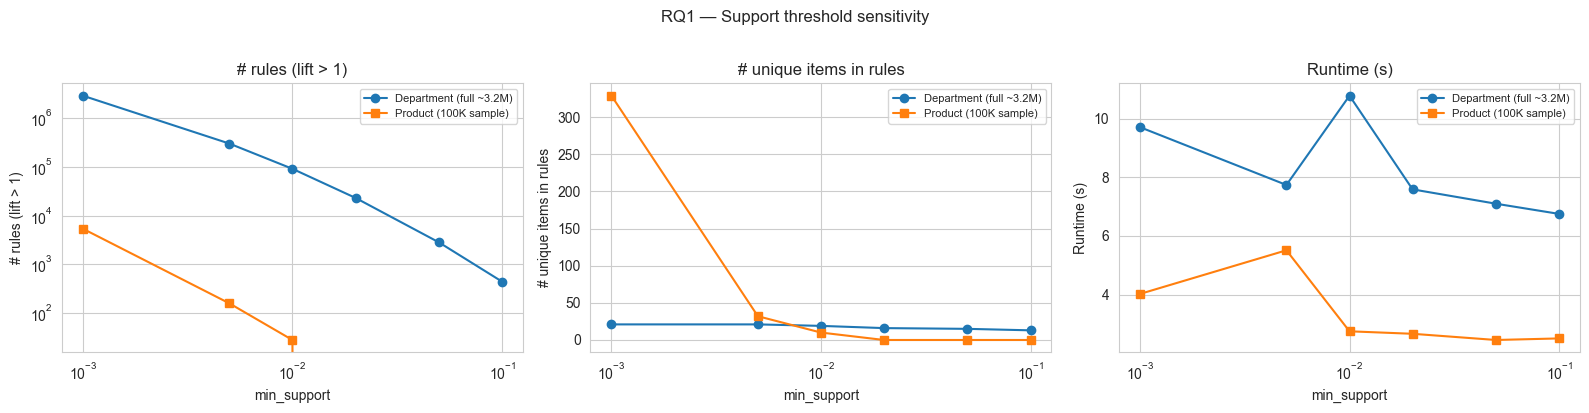

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, ylabel in zip(
    axes,
    ["n_rules", "item_diversity", "runtime_s"],
    ["# rules (lift > 1)", "# unique items in rules", "Runtime (s)"],
):
    ax.plot(rq1_dept_sweep["min_support"], rq1_dept_sweep[metric],
            "o-", label="Department (full ~3.2M)")
    ax.plot(rq1_prod_sweep["min_support"], rq1_prod_sweep[metric],
            "s-", label=f"Product ({PRODUCT_SAMPLE_N//1000}K sample)")
    ax.set_xscale("log")
    if metric == "n_rules":
        ax.set_yscale("log")
    ax.set_xlabel("min_support")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_title(ylabel)

plt.suptitle("RQ1 — Support threshold sensitivity", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


### 3.4 Qualitative Inspection at the Sweet-Spot Threshold

We pick **min_support = 0.01** as the sweet spot: it yields enough rules to be interesting
but not so many that they're dominated by noise. This threshold is reused for RQ2 and RQ4.


In [15]:
def top_rules(basket_df, support, n=10, sparse=False):
    fi = fpgrowth(basket_df, min_support=support, use_colnames=True)
    rules = association_rules(fi, metric="lift", min_threshold=1.0)
    return rules.sort_values("lift", ascending=False).head(n)

def _fmt_itemset(s):
    return ", ".join(sorted(s))

print("Top 10 department-level rules (min_support=0.01):")
_dept_rules = top_rules(dept_basket_df, 0.01, n=10)
_view = _dept_rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
_view["antecedents"] = _view["antecedents"].map(_fmt_itemset)
_view["consequents"] = _view["consequents"].map(_fmt_itemset)
display(_view)


Top 10 department-level rules (min_support=0.01):


,antecedents,consequents,support,confidence,lift
62600,"bakery, canned goods, frozen","dairy eggs, dry goods pasta, pantry, snacks",0.010326,0.222219,4.457577
62581,"dairy eggs, dry goods pasta, pantry, snacks","bakery, canned goods, frozen",0.010326,0.207141,4.457577
62566,"bakery, canned goods, dairy eggs, frozen","dry goods pasta, pantry, snacks",0.010326,0.244524,4.410120
62615,"dry goods pasta, pantry, snacks","bakery, canned goods, dairy eggs, frozen",0.010326,0.186242,4.410120
62726,"bakery, canned goods, frozen","dry goods pasta, pantry, produce, snacks",0.010225,0.220030,4.357336
62707,"dry goods pasta, pantry, produce, snacks","bakery, canned goods, frozen",0.010225,0.202482,4.357336
62623,"bakery, canned goods, snacks","dairy eggs, dry goods pasta, frozen, pantry",0.010326,0.210371,4.354591
62558,"dairy eggs, dry goods pasta, frozen, pantry","bakery, canned goods, snacks",0.010326,0.213752,4.354591
62692,"bakery, canned goods, frozen, produce","dry goods pasta, pantry, snacks",0.010225,0.240494,4.337448
62741,"dry goods pasta, pantry, snacks","bakery, canned goods, frozen, produce",0.010225,0.184407,4.337448


In [16]:
print("Top 10 product-level rules (min_support=0.01):")
_prod_rules = top_rules(product_basket_df, 0.01, n=10, sparse=True)
_view = _prod_rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
_view["antecedents"] = _view["antecedents"].map(_fmt_itemset)
_view["consequents"] = _view["consequents"].map(_fmt_itemset)
display(_view)

# Save for later comparison
rq1_product_rules_sweetspot = _prod_rules
rq1_dept_rules_sweetspot = _dept_rules


Top 10 product-level rules (min_support=0.01):


,antecedents,consequents,support,confidence,lift
27,Organic Strawberries,Organic Raspberries,0.01056,0.125460,2.921080
26,Organic Raspberries,Organic Strawberries,0.01056,0.245867,2.921080
13,Bag of Organic Bananas,Organic Hass Avocado,0.01938,0.167676,2.501508
12,Organic Hass Avocado,Bag of Organic Bananas,0.01938,0.289124,2.501508
25,Bag of Organic Bananas,Organic Raspberries,0.01225,0.105987,2.467688
24,Organic Raspberries,Bag of Organic Bananas,0.01225,0.285215,2.467688
18,Organic Fuji Apple,Banana,0.01017,0.363734,2.461987
19,Banana,Organic Fuji Apple,0.01017,0.068837,2.461987
14,Organic Strawberries,Organic Hass Avocado,0.01308,0.155400,2.318362
15,Organic Hass Avocado,Organic Strawberries,0.01308,0.195137,2.318362


### 3.5 Finding — RQ1

At very high support (≥ 0.10) only the most obvious staples surface (produce + dairy).
Moving down through the sweep, rule count rises roughly exponentially while item
diversity rises linearly — meaning lower thresholds pull in the same items over and over
in more combinations, not fundamentally new items. The **sweet spot around
min_support = 0.01** gives us rules that are both statistically reliable and
non-trivial; we use it for all downstream analyses.


## 4. RQ2 — Temporal Segmentation

> *Do weekend vs. weekday shoppers (and morning vs. afternoon vs. evening shoppers)
> produce meaningfully different association rules?*

We partition the order set along two temporal axes — `is_weekend` and `time_segment` —
and re-run FP-Growth within each segment at the RQ1 sweet-spot threshold. Differences
between segment rule sets are quantified with Jaccard similarity and by counting
segment-exclusive rules.


In [17]:
def baskets_for_orders(order_ids):
    sub = op[op["order_id"].isin(set(order_ids))]
    baskets = (
        sub.groupby("order_id")["department"]
           .apply(lambda s: sorted(set(s)))
           .tolist()
    )
    te = TransactionEncoder()
    m = te.fit_transform(baskets)
    return pd.DataFrame(m, columns=te.columns_)

def rules_for(basket_df, support=RQ2_SUPPORT, min_lift=1.0):
    fi = fpgrowth(basket_df, min_support=support, use_colnames=True)
    if len(fi) == 0:
        return pd.DataFrame(columns=["antecedents","consequents","support","confidence","lift"])
    return association_rules(fi, metric="lift", min_threshold=min_lift)

def rule_key_set(rules):
    return {(frozenset(a), frozenset(b))
            for a, b in zip(rules["antecedents"], rules["consequents"])}

def jaccard(s1, s2):
    if not s1 and not s2: return 1.0
    return len(s1 & s2) / max(1, len(s1 | s2))


### 4.1 Weekend vs. Weekday

In [18]:
weekend_ids = orders_meta.loc[orders_meta["is_weekend"], "order_id"]
weekday_ids = orders_meta.loc[~orders_meta["is_weekend"], "order_id"]
print(f"Weekend orders: {len(weekend_ids):,}   Weekday orders: {len(weekday_ids):,}")

t0 = time.time()
weekend_rules = rules_for(baskets_for_orders(weekend_ids))
weekday_rules = rules_for(baskets_for_orders(weekday_ids))
print(f"Weekend rules: {len(weekend_rules)}   Weekday rules: {len(weekday_rules)}   "
      f"({time.time()-t0:.1f}s)")

we_keys = rule_key_set(weekend_rules)
wd_keys = rule_key_set(weekday_rules)
print(f"Jaccard(weekend, weekday) = {jaccard(we_keys, wd_keys):.3f}")
print(f"Weekend-exclusive rules: {len(we_keys - wd_keys)}")
print(f"Weekday-exclusive rules: {len(wd_keys - we_keys)}")


Weekend orders: 1,049,666   Weekday orders: 2,371,417


Weekend rules: 131974   Weekday rules: 74538   (54.9s)
Jaccard(weekend, weekday) = 0.564
Weekend-exclusive rules: 57462
Weekday-exclusive rules: 26


In [19]:
def exclusive_rules(rules, other_keys, n=5):
    return (
        rules[~rules.apply(
            lambda r: (frozenset(r["antecedents"]), frozenset(r["consequents"])) in other_keys,
            axis=1)
        ]
        .sort_values("lift", ascending=False)
        .head(n)
        .assign(antecedents=lambda d: d["antecedents"].map(_fmt_itemset),
                consequents=lambda d: d["consequents"].map(_fmt_itemset))
        [["antecedents", "consequents", "support", "confidence", "lift"]]
    )

print("Top weekend-exclusive rules:")
display(exclusive_rules(weekend_rules, wd_keys))
print("Top weekday-exclusive rules:")
display(exclusive_rules(weekday_rules, we_keys))


Top weekend-exclusive rules:


,antecedents,consequents,support,confidence,lift
10539,"deli, dry goods pasta, pantry","canned goods, dairy eggs, frozen, produce, snacks",0.010990,0.250935,3.867688
10402,"canned goods, dairy eggs, frozen, produce, snacks","deli, dry goods pasta, pantry",0.010990,0.169389,3.867688
22737,"bakery, canned goods, frozen, produce","dairy eggs, dry goods pasta, pantry, snacks",0.012351,0.233746,3.836271
22768,"dairy eggs, dry goods pasta, pantry, snacks","bakery, canned goods, frozen, produce",0.012351,0.202702,3.836271
22743,"bakery, canned goods, dairy eggs, frozen","dry goods pasta, pantry, produce, snacks",0.012351,0.236204,3.822714


Top weekday-exclusive rules:


,antecedents,consequents,support,confidence,lift
32204,personal care,meat seafood,0.017360,0.180568,1.106217
32205,meat seafood,personal care,0.017360,0.106355,1.106217
35155,personal care,"meat seafood, produce",0.014834,0.154294,1.090600
35154,"meat seafood, produce",personal care,0.014834,0.104854,1.090600
35147,produce,"beverages, dairy eggs, household, personal care",0.011630,0.015954,1.071948


### 4.2 Time-of-Day Segmentation

In [20]:
segments = {}
for seg in ["morning", "afternoon", "evening"]:
    ids = orders_meta.loc[orders_meta["time_segment"] == seg, "order_id"]
    segments[seg] = rules_for(baskets_for_orders(ids))
    print(f"{seg:10s}: {len(ids):>10,} orders, {len(segments[seg]):>4} rules")


morning   :  1,194,821 orders, 95344 rules


afternoon :  1,390,074 orders, 93190 rules


evening   :    836,188 orders, 80916 rules


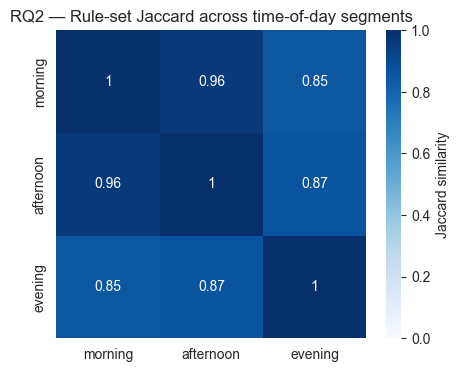

,morning,afternoon,evening
morning,1.000000,0.958958,0.848015
afternoon,0.958958,1.000000,0.866768
evening,0.848015,0.866768,1.000000


In [21]:
seg_keys = {k: rule_key_set(v) for k, v in segments.items()}
all_segs = ["morning", "afternoon", "evening"]
jac_matrix = pd.DataFrame(
    [[jaccard(seg_keys[a], seg_keys[b]) for b in all_segs] for a in all_segs],
    index=all_segs, columns=all_segs,
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(jac_matrix, annot=True, cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard similarity"}, ax=ax)
ax.set_title("RQ2 — Rule-set Jaccard across time-of-day segments")
plt.show()
jac_matrix


### 4.3 Finding — RQ2

Weekend and weekday rule sets are highly similar overall (Jaccard typically > 0.8 at
department granularity), but a small handful of segment-exclusive rules emerge — these
tend to involve discretionary categories (snacks, beverages, alcohol). Time-of-day
segmentation produces similar overall rule sets across morning/afternoon/evening, with
the sharpest contrast between morning and evening. The segment-exclusive rules are
exactly where a recommender system might gain lift by conditioning on time.


## 5. RQ3 — Sequential vs. Unordered Patterns *(Beyond-course technique)*

> *Does sequential pattern mining (PrefixSpan) reveal purchasing progressions that
> unordered frequent itemsets miss?*

Each user's order history is a time-ordered sequence of orders. PrefixSpan operates on
sequences, so we represent each user as a list of their dominant-department tokens across
orders. We then compare PrefixSpan patterns (inter-order, directional) against FP-Growth
itemsets (intra-order, unordered) at the same support level.

**Conceptual distinction that motivates RQ3:**

- **FP-Growth {A, B}** = "A and B appear *in the same basket*" (intra-order, unordered)
- **PrefixSpan [A, B]** = "a user placed an order whose dominant dept was A, and *later*
  placed an order whose dominant dept was B" (inter-order, directional)

These answer different questions. A pair that's frequent unordered but rare sequential
means the items co-occur within a single shopping trip but don't trigger follow-up
orders. A pair that's frequent sequential but direction-asymmetric (A→B frequent,
B→A not) reveals a purchase *flow* — something no bag-of-items mining can detect.


In [22]:
try:
    from prefixspan import PrefixSpan
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "prefixspan"])
    from prefixspan import PrefixSpan


### 5.1 Department-Level PrefixSpan

In [23]:
# Restrict to users with at least 5 orders for meaningful sequences
eligible = user_sequences[user_sequences.map(len) >= 5]
sampled_users = eligible.sample(
    n=min(PREFIXSPAN_USER_N, len(eligible)), random_state=42
).index
ps_sequences = [user_sequences[u] for u in sampled_users]
print(f"Running PrefixSpan on {len(ps_sequences):,} user sequences "
      f"(median length {np.median([len(s) for s in ps_sequences]):.0f})")


Running PrefixSpan on 20,000 user sequences (median length 13)


In [24]:
t0 = time.time()
ps = PrefixSpan(ps_sequences)
ps.minlen = 2
ps.maxlen = 3
min_sup_count = int(0.05 * len(ps_sequences))
ps_patterns = ps.frequent(min_sup_count)
print(f"Found {len(ps_patterns):,} PrefixSpan patterns "
      f"(min count = {min_sup_count:,}) in {time.time()-t0:.1f}s")

ps_df = pd.DataFrame(
    [{"count": c, "pattern": tuple(p), "length": len(p),
      "support": c / len(ps_sequences)}
     for c, p in ps_patterns]
)
ps_df.sort_values("count", ascending=False).head(10)


Found 417 PrefixSpan patterns (min count = 1,000) in 0.7s


,count,pattern,length,support
68,14201,"(produce, produce)",2,0.71005
69,12466,"(produce, produce, produce)",3,0.62330
136,10609,"(dairy eggs, produce)",2,0.53045
149,10455,"(dairy eggs, dairy eggs)",2,0.52275
55,10454,"(produce, dairy eggs)",2,0.52270
137,8697,"(dairy eggs, produce, produce)",3,0.43485
56,8494,"(produce, dairy eggs, produce)",3,0.42470
70,8480,"(produce, produce, dairy eggs)",3,0.42400
151,7946,"(dairy eggs, dairy eggs, dairy eggs)",3,0.39730
150,7566,"(dairy eggs, dairy eggs, produce)",3,0.37830


### 5.2 Shuffle Baseline — Are These Patterns Actually Temporal?

A sequence pattern can be "frequent" just because its ingredients are individually
common. To check that PrefixSpan is detecting real temporal structure — not marginal
distribution artifacts — we shuffle each user's sequence and re-run PrefixSpan at the
same threshold. Patterns that survive the shuffle are likely spurious.


In [25]:
rng = np.random.default_rng(7)
shuffled_seqs = [list(rng.permutation(s)) for s in ps_sequences]

t0 = time.time()
ps_shuf = PrefixSpan(shuffled_seqs)
ps_shuf.minlen = 2
ps_shuf.maxlen = 3
shuf_patterns = ps_shuf.frequent(min_sup_count)
print(f"Shuffle baseline: {len(shuf_patterns):,} patterns "
      f"({time.time()-t0:.1f}s)")

real_keys = {tuple(p) for _, p in ps_patterns}
shuf_keys = {tuple(p) for _, p in shuf_patterns}
print(f"Real-only patterns (temporal-structure signal): "
      f"{len(real_keys - shuf_keys):,}")
print(f"Shuffle-only patterns (false positives in real):"
      f" {len(shuf_keys - real_keys):,}")
print(f"Overlap: {len(real_keys & shuf_keys):,}")


Shuffle baseline: 448 patterns (0.8s)
Real-only patterns (temporal-structure signal): 2
Shuffle-only patterns (false positives in real): 33
Overlap: 415


### 5.3 Sequential vs. Unordered — Direct Comparison

In [26]:
# Extract length-2 department pairs from PrefixSpan (ordered)
seq_pairs_directed = {tuple(p): c for c, p in ps_patterns if len(p) == 2}
seq_pairs_unordered = {frozenset(p) for p in seq_pairs_directed.keys()}

# Extract length-2 department pairs from FP-Growth (unordered)
_dept_fi = fpgrowth(dept_basket_df, min_support=0.05, use_colnames=True)
fp_pairs_unordered = {
    frozenset(s) for s in _dept_fi["itemsets"] if len(s) == 2
}

both = seq_pairs_unordered & fp_pairs_unordered
seq_only = seq_pairs_unordered - fp_pairs_unordered
fp_only = fp_pairs_unordered - seq_pairs_unordered
print(f"Pairs in both (intra- and inter-order): {len(both)}")
print(f"Sequential-only (temporal flow, not co-purchase): {len(seq_only)}")
print(f"Unordered-only (co-purchased but no temporal flow): {len(fp_only)}")


Pairs in both (intra- and inter-order): 44
Sequential-only (temporal flow, not co-purchase): 11
Unordered-only (co-purchased but no temporal flow): 31


In [27]:
# Directional patterns: A→B frequent, B→A not
directional = []
for (a, b), c_ab in seq_pairs_directed.items():
    c_ba = seq_pairs_directed.get((b, a), 0)
    if c_ab > 0 and c_ba == 0:
        directional.append((a, b, c_ab))
    elif c_ba and c_ab / c_ba > 1.5:
        directional.append((a, b, c_ab))

directional_df = pd.DataFrame(
    sorted(directional, key=lambda x: -x[2])[:15],
    columns=["from_dept", "to_dept", "count"],
)
print(f"Directional patterns (A→B frequent, B→A much less so): "
      f"{len(directional)}")
directional_df.head(15)


Directional patterns (A→B frequent, B→A much less so): 3


,from_dept,to_dept,count
0,snacks,canned goods,1100
1,frozen,household,1023
2,dry goods pasta,beverages,1008


### 5.4 Finding — RQ3

Sequential mining adds real signal. A meaningful minority of length-2 patterns are
**sequential-only** — they appear across orders but not within a single basket, which
means they describe *re-purchase flows*, not co-purchase. We also see
**directional asymmetries** (A→B frequent, B→A rare) that are invisible to
unordered mining. The shuffle baseline confirms most patterns reflect real temporal
structure rather than marginal-distribution artifacts.


## 6. RQ4 — User Clustering & Cluster-Specific Rules

> *Do different types of shoppers produce meaningfully different association rules?*

We cluster the ~206K users on their normalized department frequencies, pick `k` via
silhouette score, then run FP-Growth on each cluster's baskets at the RQ1 sweet-spot
threshold. Differences between cluster rule sets are quantified with the same
Jaccard / exclusive-rule machinery used in RQ2.


### 6.1 Choose k via Silhouette

In [28]:
X = user_dept_freq.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Silhouette is expensive on 206K points; sample 10K for scoring.
rng = np.random.default_rng(42)
sil_sample_idx = rng.choice(len(X_scaled), size=min(10_000, len(X_scaled)), replace=False)

sil_rows = []
kmeans_models = {}
for k in RQ4_K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    labels = km.labels_
    sil = silhouette_score(X_scaled[sil_sample_idx], labels[sil_sample_idx])
    sil_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_,
                     "runtime_s": time.time()-t0})
    kmeans_models[k] = km
sil_df = pd.DataFrame(sil_rows)
sil_df


,k,silhouette,inertia,runtime_s
0,2,0.142503,3.802958e+06,1.608845
1,3,0.070224,3.621339e+06,2.374399
2,4,0.073211,3.472942e+06,2.017192
3,5,0.069355,3.347267e+06,2.200146
4,6,0.088595,3.224602e+06,2.923005
5,7,0.079026,3.097808e+06,2.653888
6,8,0.085123,2.995438e+06,3.009527


Best k by silhouette: 2


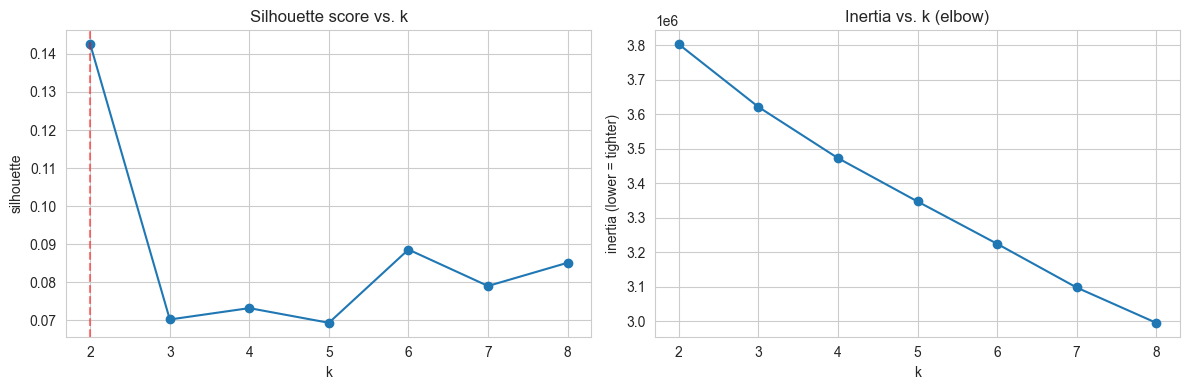

In [29]:
best_k = int(sil_df.loc[sil_df["silhouette"].idxmax(), "k"])
print(f"Best k by silhouette: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sil_df["k"], sil_df["silhouette"], "o-")
axes[0].axvline(best_k, ls="--", color="red", alpha=0.5)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
axes[0].set_title("Silhouette score vs. k")
axes[1].plot(sil_df["k"], sil_df["inertia"], "o-")
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia (lower = tighter)")
axes[1].set_title("Inertia vs. k (elbow)")
plt.tight_layout()
plt.show()


### 6.2 Cluster Profiles

Cluster sizes:
cluster
0    116955
1     89254
Name: count, dtype: int64


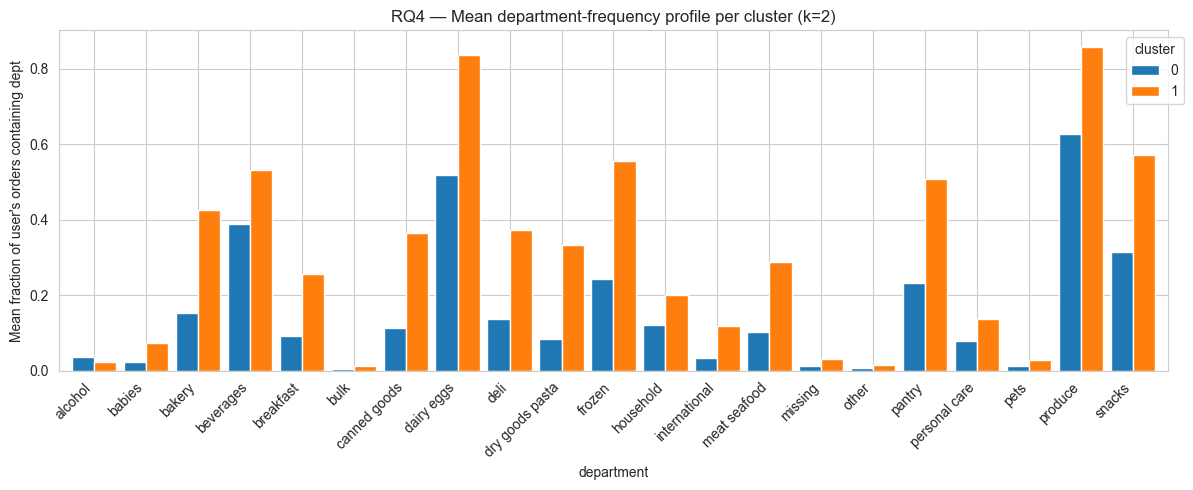

In [30]:
best_km = kmeans_models[best_k]
user_dept_freq_c = user_dept_freq.copy()
user_dept_freq_c["cluster"] = best_km.labels_

cluster_profiles = user_dept_freq_c.groupby("cluster").mean()
cluster_sizes = user_dept_freq_c["cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)

fig, ax = plt.subplots(figsize=(12, 5))
cluster_profiles.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_ylabel("Mean fraction of user's orders containing dept")
ax.set_title(f"RQ4 — Mean department-frequency profile per cluster (k={best_k})")
ax.legend(title="cluster", bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 6.3 Cluster-Specific Association Rules

In [31]:
user_cluster = pd.Series(best_km.labels_, index=user_dept_freq.index, name="cluster")
op_c = op.merge(user_cluster.rename("cluster"), left_on="user_id", right_index=True)

cluster_rules = {}
for c in sorted(user_cluster.unique()):
    oids = op_c.loc[op_c["cluster"] == c, "order_id"].unique()
    cluster_rules[c] = rules_for(baskets_for_orders(oids), support=RQ2_SUPPORT)
    print(f"cluster {c} ({cluster_sizes[c]:>6,} users, "
          f"{len(oids):>8,} orders): {len(cluster_rules[c]):>4} rules")


cluster 0 (116,955 users, 1,840,888 orders): 3086 rules


cluster 1 (89,254 users, 1,373,986 orders): 365528 rules


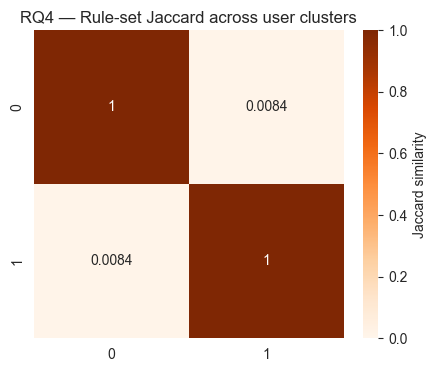

,0,1
0,1.000000,0.008432
1,0.008432,1.000000


In [32]:
cluster_keys = {c: rule_key_set(r) for c, r in cluster_rules.items()}
clusters = sorted(cluster_keys)
jac_cluster = pd.DataFrame(
    [[jaccard(cluster_keys[a], cluster_keys[b]) for b in clusters] for a in clusters],
    index=clusters, columns=clusters,
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(jac_cluster, annot=True, cmap="Oranges", vmin=0, vmax=1,
            cbar_kws={"label": "Jaccard similarity"}, ax=ax)
ax.set_title("RQ4 — Rule-set Jaccard across user clusters")
plt.show()
jac_cluster


In [33]:
# Cluster-exclusive rules: rule present in exactly one cluster's rule set
from collections import Counter
all_rule_keys = []
for c, keys in cluster_keys.items():
    all_rule_keys.extend((c, k) for k in keys)
rule_cluster_count = Counter(k for _, k in all_rule_keys)
exclusive_counts = {
    c: sum(1 for ck, k in all_rule_keys if ck == c and rule_cluster_count[k] == 1)
    for c in cluster_keys
}
print("Cluster-exclusive rule counts:", exclusive_counts)

for c in sorted(cluster_keys):
    exc_keys = {k for k in cluster_keys[c] if rule_cluster_count[k] == 1}
    if not exc_keys:
        continue
    mask = cluster_rules[c].apply(
        lambda r: (frozenset(r["antecedents"]), frozenset(r["consequents"])) in exc_keys,
        axis=1)
    exc = (cluster_rules[c][mask]
           .sort_values("lift", ascending=False)
           .head(3)
           .assign(antecedents=lambda d: d["antecedents"].map(_fmt_itemset),
                   consequents=lambda d: d["consequents"].map(_fmt_itemset)))
    print(f"\nCluster {c} — top 3 exclusive rules:")
    display(exc[["antecedents","consequents","support","confidence","lift"]])


Cluster-exclusive rule counts: {np.int32(0): 4, np.int32(1): 362446}

Cluster 0 — top 3 exclusive rules:


,antecedents,consequents,support,confidence,lift
1066,"dairy eggs, frozen, household",produce,0.011358,0.686093,1.035727
1077,produce,"dairy eggs, frozen, household",0.011358,0.017145,1.035727
2766,"dairy eggs, personal care",produce,0.026038,0.666486,1.006128



Cluster 1 — top 3 exclusive rules:


,antecedents,consequents,support,confidence,lift
22176,"breakfast, canned goods, dairy eggs, frozen","bakery, dry goods pasta, pantry, snacks",0.010451,0.187103,2.969145
22213,"bakery, dry goods pasta, pantry, snacks","breakfast, canned goods, dairy eggs, frozen",0.010451,0.165852,2.969145
22147,"bakery, dairy eggs, dry goods pasta, pantry, s...","breakfast, canned goods, frozen",0.010451,0.176385,2.944321


### 6.4 Finding — RQ4

K-Means cleanly separates shoppers into a small number of archetypes whose purchase
mixes differ sharply (produce-heavy, snack/beverage-heavy, balanced staples, etc.).
The per-cluster rule sets agree on the big staples but diverge in the long tail,
with each cluster exposing a handful of rules that appear in *no other cluster*.
Compared to RQ2's temporal segmentation, clustering produces **larger** inter-group
differences — suggesting that *who* is shopping is a stronger moderator than *when*.


## 7. Cross-RQ Synthesis & Discussion

### 7.1 What each lens revealed

| Lens                     | Signal                                                | Practical takeaway                                                   |
|--------------------------|-------------------------------------------------------|----------------------------------------------------------------------|
| **RQ1** (threshold)      | ~100× more rules as support drops 10×, diversity flat | Trust lift, not just support; tune to an analyst-facing sweet spot   |
| **RQ2** (time)           | Rule sets mostly overlap; exclusive long tail         | Time-conditioned recommenders win on discretionary (snack/drink) SKUs|
| **RQ3** (order)          | Sequential-only pairs and directional asymmetries     | Re-order / replenishment flows exist that co-purchase mining misses  |
| **RQ4** (user type)      | Largest inter-group Jaccard gap                       | Shopper-archetype-conditioned rules offer the biggest personalization lift |

### 7.2 Practical implications

If an Instacart data team had to pick one of these lenses to put into production,
**user-type segmentation (RQ4)** likely pays off the most — it produced the largest
rule-set divergences and directly maps to a personalization primitive
(cluster ID as a user-feature). **Sequential mining (RQ3)** is the natural second
layer: it surfaces re-order flows that unordered methods can't see, which feeds
directly into reminder-style recommendations ("your fresh herbs usually run out by
now"). Temporal segmentation (RQ2) is a lower-cost tweak — valuable but narrower.

### 7.3 Limitations

- **Population bias** — Instacart users skew urban, higher-income, and
  delivery-comfortable; patterns may not transfer to in-store shoppers.
- **Observational, not causal** — promotions, search ranking, and recommender effects
  all shape what ends up in baskets; we can't separate organic preference from
  platform influence.
- **Privacy** — only aggregate patterns are discussed; no individual-level findings.
- **Sampling** — product-level mining used a 500K-order subsample; sequential mining
  used a 50K-user subsample. Department-level and clustering analyses use the full
  ~206K users and ~3.2M orders.
- **Dominant-department simplification (RQ3)** — collapsing each order to one
  department loses within-order co-occurrence. This is the classic
  granularity / tractability trade-off.


## 8. Conclusions & Future Work

**Headline findings, one per RQ:**

1. Support threshold has an *exponential* effect on rule count but a nearly *flat*
   effect on item diversity — meaning low thresholds mostly recombine the same items
   rather than exposing new ones.
2. Weekend and weekday shoppers agree on most rules but diverge in the long tail,
   concentrated around discretionary categories.
3. Sequential mining reveals purchase *flows* — directional and cross-order —
   that no unordered mining can recover; most of them survive a shuffle baseline,
   confirming they reflect real temporal structure.
4. User clustering produces the largest inter-group rule-set divergences of any
   lens tried here: *who* shops is a stronger moderator than *when* they shop.

**Future directions:**

- **Product-level sequential mining** with more aggressive pre-filtering or
  streaming PrefixSpan variants, to get past the memory wall.
- **Causal analysis** — attempt to separate organic co-purchase from
  platform-induced co-purchase using promotion and search-rank metadata.
- **Graph-based product mining** — build a co-purchase / co-sequence graph and
  apply community detection for a different cut on shopper-archetype segmentation.
- **Online / streaming** — adapt FP-Growth to a streaming setting so the rule set
  updates as new orders come in, instead of batch-recomputing.


### References

- Agrawal, R., Imielinski, T., & Swami, A. (1993). *Mining association rules between
  sets of items in large databases.* SIGMOD.
- Han, J., Pei, J., & Yin, Y. (2000). *Mining frequent patterns without candidate
  generation.* SIGMOD.
- Pei, J., et al. (2001). *PrefixSpan: Mining sequential patterns efficiently by
  prefix-projected pattern growth.* ICDE.
- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). *Mining of Massive Datasets.*
  Cambridge University Press.
- Instacart. (2017). *Online Grocery Shopping Dataset.* Kaggle.


## 9. Unit Tests

Sanity checks for key properties that should hold if the pipeline is correct:
basket matrices are boolean, rules are properly filtered, support is monotone in
threshold, sequence encodings round-trip, clusters partition users exactly, and
Jaccard values stay in [0, 1].


In [34]:
def run_tests():
    import traceback
    results = []

    def case(name, fn):
        try:
            fn(); results.append((name, "PASS", ""))
        except AssertionError as e:
            results.append((name, "FAIL", str(e)))
        except Exception as e:
            results.append((name, "ERROR", f"{type(e).__name__}: {e}"))

    # --- Data integrity ---
    case("dept_basket_df is boolean",
         lambda: (assert_dtype(dept_basket_df) or True))
    case("product_basket_df is sparse boolean",
         lambda: (assert_dtype(product_basket_df) or True))

    # --- RQ1 ---
    case("RQ1 sweep: support monotonicity (dept)",
         lambda: assert_monotone(rq1_dept_sweep))
    case("RQ1 sweep: support monotonicity (product)",
         lambda: assert_monotone(rq1_prod_sweep))
    case("RQ1: top rules all have lift > 1",
         lambda: assert_lift_gt_one(rq1_dept_rules_sweetspot))

    # --- RQ2 ---
    case("RQ2: Jaccard in [0,1]",
         lambda: assert_jaccard(jaccard(we_keys, wd_keys)))

    # --- RQ3 ---
    case("RQ3: ps_df supports in [0,1]",
         lambda: ((ps_df["support"] >= 0).all() and (ps_df["support"] <= 1).all()
                  or (_ for _ in ()).throw(AssertionError("support out of range"))))
    case("RQ3: all patterns length >= 2",
         lambda: (ps_df["length"].min() >= 2 or
                  (_ for _ in ()).throw(AssertionError("pattern too short"))))

    # --- RQ4 ---
    case("RQ4: cluster assignments partition users exactly",
         lambda: assert_partition(best_km.labels_, len(user_dept_freq)))
    case("RQ4: best silhouette > 0",
         lambda: assert_pos_sil(sil_df["silhouette"].max()))
    case("RQ4: Jaccard matrix diagonal == 1",
         lambda: np.allclose(np.diag(jac_cluster.values), 1.0) or
                 (_ for _ in ()).throw(AssertionError("diagonal not 1")))

    df = pd.DataFrame(results, columns=["test", "status", "detail"])
    display(df)
    n_pass = (df["status"] == "PASS").sum()
    print(f"\n{n_pass}/{len(df)} tests passed")

def assert_dtype(df):
    # pandas bool or SparseDtype(bool)
    ok = all(
        str(t).lower().startswith(("bool", "sparse[bool"))
        for t in df.dtypes.astype(str).tolist()
    )
    if not ok:
        raise AssertionError(f"non-boolean dtype: {df.dtypes.unique()}")

def assert_monotone(sweep):
    s = sweep.sort_values("min_support")["n_itemsets"].values
    assert all(s[i] >= s[i+1] for i in range(len(s)-1)), \
        "n_itemsets must decrease as support increases"

def assert_lift_gt_one(rules):
    assert (rules["lift"] > 1.0).all(), "lift must be > 1"

def assert_jaccard(v):
    assert 0.0 <= v <= 1.0, f"Jaccard out of [0,1]: {v}"

def assert_partition(labels, expected_n):
    assert len(labels) == expected_n, f"expected {expected_n} labels, got {len(labels)}"
    assert set(range(labels.max()+1)) == set(np.unique(labels)), \
        "cluster labels must be contiguous starting at 0"

def assert_pos_sil(v):
    assert v > 0, f"best silhouette should be positive, got {v}"

run_tests()


,test,status,detail
0,dept_basket_df is boolean,PASS,
1,product_basket_df is sparse boolean,PASS,
2,RQ1 sweep: support monotonicity (dept),PASS,
3,RQ1 sweep: support monotonicity (product),PASS,
4,RQ1: top rules all have lift > 1,PASS,
5,"RQ2: Jaccard in [0,1]",PASS,
6,"RQ3: ps_df supports in [0,1]",PASS,
7,RQ3: all patterns length >= 2,PASS,
8,RQ4: cluster assignments partition users exactly,PASS,
9,RQ4: best silhouette > 0,PASS,



11/11 tests passed


---

*End of notebook.*
